# Exploración inicial

Este cuaderno documenta la **fase exploratoria** del proyecto. Hay harto código sucio.

## Columnas del DTPM: por qué se nombran a mano

El Excel de paraderos del DTPM no trae encabezados tan limpios: vienen con saltos de línea, guiones partidos y espacios dobles. Por eso en la función `cargar_buses` las columnas se renombran por posición.

In [1]:
import pandas as pd
from evasion.config import DTPM
# Encabezados crudos del Excel del DTPM (primeros 8)
print(list(pd.read_excel(DTPM, nrows=0).columns)[:8])

['Orden\nCirc.', 'Código TS', 'Código Usuario', 'Sentido Servicio', 'Varian-te', 'UN', 'Código paradero TS', 'Código  paradero Usuario']


## 1. Generación de candidatos: matching CDR–Bip

Primer cruce espacio-temporal entre los pings del celular y las validaciones Bip,
con radio de 100 m y ventana de ±3 min. Esta lógica quedó luego en `evasion/matching.py`.

In [1]:
# NOTA: celda de registro. El recálculo está comentado para no
# correr el matching completo de nuevo (ya está en data/candidatos.parquet).
import sys, datetime
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from evasion.telefonia import procesar_cdr
# from evasion.matching import generar_candidatos
import pandas as pd

# Carga CDR
# cdr = procesar_cdr()

# Solo nov 1-7, días con validaciones Bip
# cdr = cdr[cdr['fecha'].between(datetime.date(2023, 11, 1), datetime.date(2023, 11, 7))].copy()
print(f"CDR filtrado Nov 1-7: {cdr['user_id'].nunique():,} usuarios, {len(cdr):,} registros")

# Matching con parámetros ajustados
# candidatos = generar_candidatos(cdr, radio_m=100, ventana_min=3)

# Guardar
# candidatos.to_parquet(r"C:\Users\User\Desktop\u\memoria\E\prevwork\data\candidatos.parquet", index=False)
# print("Guardado.")


Archivos CDR encontrados: 5
Registros tras carga inicial: 27,580,194
Usuarios tras carga inicial: 22,343
Usuarios tras filtro fracción RM (>=80%): 22,343
Usuarios tras filtro días (>=5 pings/día): 22,343
Registros finales: 27,405,224
CDR filtrado Nov 1-7: 20,282 usuarios, 5,281,746 registros
Días Bip a procesar: 7 | Radio: 100m | Ventana: ±3min

2023-11-01 — CDR: 700,495 pings | Bip: 1,185,673 viajes
  chunk 1: 146,809 candidatos
  chunk 2: 148,892 candidatos
  chunk 3: 153,570 candidatos
  chunk 4: 145,609 candidatos
  chunk 5: 149,909 candidatos
  chunk 6: 133,104 candidatos

2023-11-02 — CDR: 782,174 pings | Bip: 3,321,915 viajes
  chunk 1: 291,896 candidatos
  chunk 2: 246,741 candidatos
  chunk 3: 251,724 candidatos
  chunk 4: 282,588 candidatos
  chunk 5: 259,220 candidatos
  chunk 6: 271,860 candidatos
  chunk 7: 284,525 candidatos
  chunk 8: 281,841 candidatos
  chunk 9: 279,567 candidatos
  chunk 10: 274,497 candidatos
  chunk 11: 267,618 candidatos
  chunk 12: 264,687 candida

## 2. Co-ocurrencia entre días (cross-day)

Para cada par (usuario, tarjeta) se cuenta en cuántos días distintos coinciden. Aquí
se exploró el umbral: coincidir 3 o más días es la evidencia que define a un validador
consistente. Quedó en `evasion/crossday.py`.

In [2]:
import pandas as pd

candidatos = pd.read_parquet('../data/candidatos.parquet')
print(f"Candidatos totales: {len(candidatos):,}")

# Agregar id_tarjeta — día a día para no cargar todo Bip en RAM
resultados = []
for fecha in sorted(candidatos['fecha'].unique()):
    viajes_dia = pd.read_parquet(
        f'../data/viajes/parquet/{fecha}.parquet',
        columns=['lat_subida', 'lon_subida', 'tiempo_subida_1', 'id_tarjeta']
    )
    # Mismo preproceso que matching.py para que idx_bip coincida
    viajes_dia['ts'] = pd.to_datetime(viajes_dia['tiempo_subida_1'], errors='coerce')
    viajes_dia = viajes_dia.dropna(subset=['lat_subida', 'lon_subida', 'ts']).reset_index(drop=True)

    c = candidatos[candidatos['fecha'] == fecha].copy()
    c['id_tarjeta'] = viajes_dia.loc[c['idx_bip'], 'id_tarjeta'].values
    resultados.append(c)
    print(f"  {fecha}: {len(c):,} candidatos procesados", flush=True)
    del viajes_dia

candidatos = pd.concat(resultados, ignore_index=True)
print(f"\nCon id_tarjeta: {len(candidatos):,} filas")

# Análisis cross-day
pares = (candidatos
    .groupby(['usuario', 'id_tarjeta'])['fecha']
    .nunique()
    .reset_index(name='n_dias'))

print("\nDías juntos por par (usuario CDR, tarjeta Bip):")
print(pares['n_dias'].value_counts().sort_index())

total_usuarios = candidatos['usuario'].nunique()
usuarios_3dias = pares[pares['n_dias'] >= 3]['usuario'].nunique()
usuarios_2dias = pares[pares['n_dias'] >= 2]['usuario'].nunique()

print(f"\nTotal usuarios CDR en candidatos : {total_usuarios:,}")
print(f"Usuarios con match 2+ días       : {usuarios_2dias:,} ({usuarios_2dias/total_usuarios*100:.1f}%)")
print(f"Usuarios con match 3+ días       : {usuarios_3dias:,} ({usuarios_3dias/total_usuarios*100:.1f}%)")
print(f"Usuarios sin match consistente   : {total_usuarios - usuarios_2dias:,} ({(total_usuarios-usuarios_2dias)/total_usuarios*100:.1f}%)")


Candidatos totales: 23,008,202
  2023-11-01: 877,893 candidatos procesados
  2023-11-02: 4,508,337 candidatos procesados
  2023-11-03: 4,722,752 candidatos procesados
  2023-11-04: 2,003,943 candidatos procesados
  2023-11-05: 752,150 candidatos procesados
  2023-11-06: 5,022,927 candidatos procesados
  2023-11-07: 5,120,200 candidatos procesados

Con id_tarjeta: 23,008,202 filas

Días juntos por par (usuario CDR, tarjeta Bip):
n_dias
1    13219744
2      283249
3       27589
4        3673
5         418
6          40
7           2
Name: count, dtype: int64

Total usuarios CDR en candidatos : 16,211
Usuarios con match 2+ días       : 6,405 (39.5%)
Usuarios con match 3+ días       : 1,852 (11.4%)
Usuarios sin match consistente   : 9,806 (60.5%)


## 3. Ingeniería de features (exploración)

Se probaron varias características de movilidad por usuario. Algunas que aparecen aquí
(`bbox_km` = área de movimiento, `frac_paradero_top`, `frac_noche`) se **descartaron**
en la versión final, que quedó con 8 features en `evasion/features.py`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# Preparar paraderos 
paraderos = pd.read_csv('../data/gtfs/paradas/paraderos_coords.csv')
paraderos = paraderos.dropna(subset=['lat', 'lon']).reset_index(drop=True)

coords_paraderos = np.radians(paraderos[['lat', 'lon']].values)
arbol_paraderos  = BallTree(coords_paraderos, metric='haversine')

# Marcar cada ping CDR 
RADIO_METROS = 200

coords_cdr          = np.radians(cdr[['lat', 'lon']].values)
distancias, indices = arbol_paraderos.query(coords_cdr, k=1)
distancias_metros   = distancias.flatten() * 6_371_000
indices_paradero    = indices.flatten()

cdr = cdr.copy()
cdr['hora']          = pd.to_datetime(cdr['timestamp']).dt.hour
cdr['cerca_paradero'] = distancias_metros < RADIO_METROS
cdr['paradero_id']   = np.where(cdr['cerca_paradero'], indices_paradero, -1)

# features básicos 
n_pings = cdr.groupby('user_id').size().reset_index(name='n_pings')

n_dias = cdr.groupby('user_id')['fecha'].nunique().reset_index(name='n_dias_activos')

cdr['en_horario'] = (cdr['hora'] >= 6) & (cdr['hora'] <= 22)
frac_horario = cdr.groupby('user_id')['en_horario'].mean().reset_index(name='frac_horario_trans')

frac_paradero = cdr.groupby('user_id')['cerca_paradero'].mean().reset_index(name='frac_cerca_paradero')

# velocidad entre pings consecutivos del mismo usuario
cdr_ord = cdr.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

cdr_ord['lat_ant']    = cdr_ord.groupby('user_id')['lat'].shift(1)
cdr_ord['lon_ant']    = cdr_ord.groupby('user_id')['lon'].shift(1)
cdr_ord['tiempo_ant'] = cdr_ord.groupby('user_id')['timestamp'].shift(1)

pares = cdr_ord.dropna(subset=['lat_ant']).copy()

def haversine_metros(lat1, lon1, lat2, lon2):
    R    = 6_371_000
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

pares['dist_m']  = haversine_metros(pares['lat_ant'], pares['lon_ant'], pares['lat'], pares['lon'])
pares['dt_min']  = (pares['timestamp'] - pares['tiempo_ant']).dt.total_seconds() / 60
pares['vel_kmh'] = (pares['dist_m'] / 1000) / (pares['dt_min'] / 60 + 0.0001)

vel_mediana = pares.groupby('user_id')['vel_kmh'].median().reset_index(name='vel_mediana')
vel_p90     = pares.groupby('user_id')['vel_kmh'].quantile(0.9).reset_index(name='vel_p90')

In [ ]:
def diagonal_bbox_km(grupo):
    dif_lat_km = (grupo['lat'].max() - grupo['lat'].min()) * 111
    dif_lon_km = (grupo['lon'].max() - grupo['lon'].min()) * 85
    return (dif_lat_km**2 + dif_lon_km**2) ** 0.5

bbox = cdr.groupby('user_id').apply(diagonal_bbox_km, include_groups=False)
bbox = bbox.reset_index(name='bbox_km')

pings_en_paradero = cdr[cdr['paradero_id'] != -1].copy()

n_paraderos = (pings_en_paradero
    .groupby('user_id')['paradero_id']
    .nunique()
    .reset_index(name='n_paraderos_distintos'))

def fraccion_paradero_top(grupo):
    conteo = grupo['paradero_id'].value_counts()
    return conteo.iloc[0] / len(grupo)

frac_top = (pings_en_paradero
    .groupby('user_id')
    .apply(fraccion_paradero_top, include_groups=False)
    .reset_index(name='frac_paradero_top'))

cdr['es_manana'] = (cdr['hora'] >= 6) & (cdr['hora'] < 12)
frac_manana = cdr.groupby('user_id')['es_manana'].mean().reset_index(name='frac_manana')

cdr['es_noche'] = (cdr['hora'] >= 12) & (cdr['hora'] < 20)
frac_noche = cdr.groupby('user_id')['es_noche'].mean().reset_index(name='frac_noche')

# Juntar todo 

features = n_pings.copy()
features = features.merge(n_dias,         on='user_id', how='left')
features = features.merge(frac_horario,   on='user_id', how='left')
features = features.merge(frac_paradero,  on='user_id', how='left')
features = features.merge(vel_mediana,    on='user_id', how='left')
features = features.merge(vel_p90,        on='user_id', how='left')
features = features.merge(bbox,           on='user_id', how='left')
features = features.merge(n_paraderos,    on='user_id', how='left').fillna({'n_paraderos_distintos': 0})
features = features.merge(frac_top,       on='user_id', how='left').fillna({'frac_paradero_top': 0})
features = features.merge(frac_manana,    on='user_id', how='left').fillna({'frac_manana': 0})
features = features.merge(frac_noche,     on='user_id', how='left').fillna({'frac_noche': 0})
print(features.head())

   user_id  n_pings  n_dias_activos  frac_horario_trans  frac_cerca_paradero  \
0        0       69               7                 1.0             1.000000   
1        2      754               7                 1.0             0.992042   
2        3       17               2                 1.0             0.411765   
3        4       57               3                 1.0             0.298246   
4       17       54               3                 1.0             0.092593   

   vel_mediana      vel_p90    bbox_km  n_paraderos_distintos  \
0     0.201643     2.401599   3.010381                   16.0   
1     0.401382     2.093527   0.527262                    6.0   
2    24.782977   148.010007  27.480561                    7.0   
3     7.216759   220.310429   3.889220                    7.0   
4     0.694000  1039.891660   5.612033                    4.0   

   frac_paradero_top  frac_manana  frac_noche  
0           0.246377     0.347826    0.550725  
1           0.895722     0.37267

## 4. Etiquetado de grupos de usuarios

Asignación de cada usuario a un grupo según su co-ocurrencia con tarjetas. Los nombres
de esta etapa (*pagador_confirmado*, *sin_candidatos*, *sin_match_consistente*) son
preliminares; en la versión final se renombraron a *validador_consistente*,
*sin_uso_aparente*, etc.

In [5]:
# Agregar info de cross-day desde candidatos
pares_cd   = candidatos.groupby(['usuario', 'id_tarjeta'])['fecha'].nunique().reset_index(name='n_dias_juntos')
n_dias_max = pares_cd.groupby('usuario')['n_dias_juntos'].max().reset_index(name='n_dias_max_tarjeta')
n_tarjetas = candidatos.groupby('usuario')['id_tarjeta'].nunique().reset_index(name='n_tarjetas')

features = features.merge(n_dias_max.rename(columns={'usuario':'user_id'}), on='user_id', how='left')
features = features.merge(n_tarjetas.rename(columns={'usuario':'user_id'}),  on='user_id', how='left')
features['n_dias_max_tarjeta'] = features['n_dias_max_tarjeta'].fillna(0).astype(int)
features['n_tarjetas']         = features['n_tarjetas'].fillna(0).astype(int)

# Etiquetar cada usuario
def etiquetar(fila):
    if fila['n_dias_max_tarjeta'] >= 3:  return 'pagador_confirmado'
    if fila['n_tarjetas'] == 0:           return 'sin_candidatos'
    if fila['n_dias_max_tarjeta'] == 2:   return 'ambiguo'
    return 'sin_match_consistente'

features['grupo'] = features.apply(etiquetar, axis=1)

# Ver tabla resumen
cols_ver = ['n_pings', 'frac_cerca_paradero', 'vel_mediana',
            'bbox_km', 'n_paraderos_distintos', 'frac_paradero_top']
print("Mediana por grupo:")
print(features.groupby('grupo')[cols_ver].median().round(2))

features.to_parquet('../data/features_usuarios.parquet', index=False)
print(f"\nGuardado: {len(features):,} usuarios con {len(features.columns)} columnas")


Mediana por grupo:
                       n_pings  frac_cerca_paradero  vel_mediana  bbox_km  \
grupo                                                                       
ambiguo                  332.0                 0.88         2.59    17.03   
pagador_confirmado       583.0                 0.92         2.71    16.82   
sin_candidatos            55.0                 0.00         1.83     8.49   
sin_match_consistente     86.0                 0.83         1.60    10.82   

                       n_paraderos_distintos  frac_paradero_top  
grupo                                                            
ambiguo                                 51.0               0.27  
pagador_confirmado                      61.0               0.33  
sin_candidatos                           0.0               0.00  
sin_match_consistente                   13.0               0.33  

Guardado: 20,282 usuarios con 15 columnas


## 5. Detección de outliers de movilidad

Al revisar `bbox_km` se encontraron usuarios con área de movimiento mayor a 100 km,
imposible dentro de la Región Metropolitana (errores de triangulación). Se decidió
recortar a 50 km. Más adelante la feature `bbox_km` se descartó por completo, pero la
detección de outliers fue útil para entender la calidad del dato.

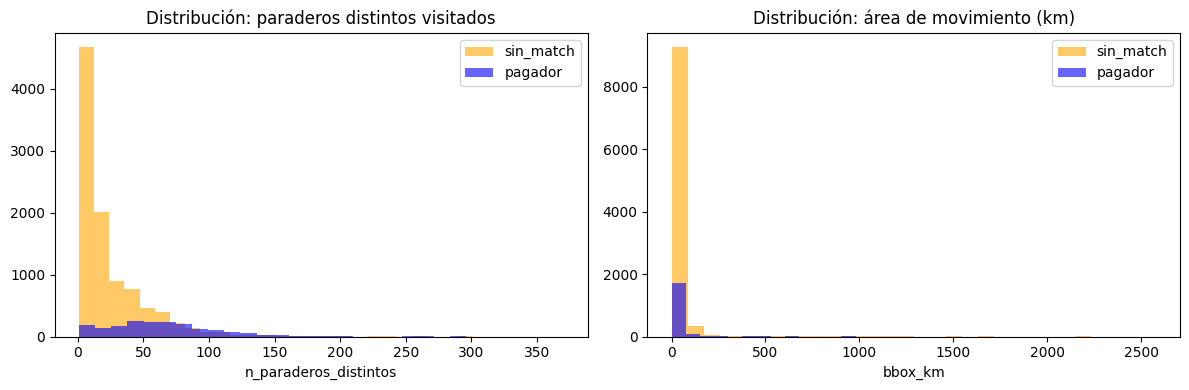

In [6]:
import matplotlib.pyplot as plt

grupo_smc = features[features['grupo'] == 'sin_match_consistente']
grupo_pag = features[features['grupo'] == 'pagador_confirmado']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de n_paraderos_distintos
axes[0].hist(grupo_smc['n_paraderos_distintos'], bins=30, alpha=0.6, label='sin_match', color='orange')
axes[0].hist(grupo_pag['n_paraderos_distintos'], bins=30, alpha=0.6, label='pagador',   color='blue')
axes[0].set_title('Distribución: paraderos distintos visitados')
axes[0].set_xlabel('n_paraderos_distintos')
axes[0].legend()

# Distribución de bbox_km
axes[1].hist(grupo_smc['bbox_km'], bins=30, alpha=0.6, label='sin_match', color='orange')
axes[1].hist(grupo_pag['bbox_km'], bins=30, alpha=0.6, label='pagador',   color='blue')
axes[1].set_title('Distribución: área de movimiento (km)')
axes[1].set_xlabel('bbox_km')
axes[1].legend()

plt.tight_layout()
plt.show()


In [7]:
# Ver cuántos usuarios tienen bbox absurdo (>100km es imposible dentro de la RM)
print(features['bbox_km'].describe())
print(f"Usuarios con bbox > 100km: {(features['bbox_km'] > 100).sum():,}")

# Limitar a un máximo razonable para la RM (50km es el ancho de Santiago)
features['bbox_km'] = features['bbox_km'].clip(upper=50)


count    20282.000000
mean        32.061974
std        115.662598
min          0.000000
25%          4.350676
50%         12.442691
75%         24.909677
max       2578.209823
Name: bbox_km, dtype: float64
Usuarios con bbox > 100km: 840


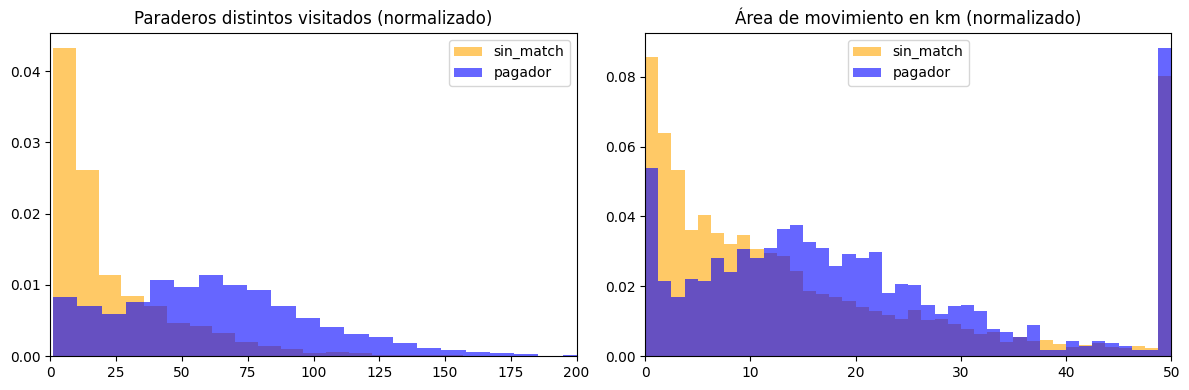

In [8]:
import matplotlib.pyplot as plt

grupo_smc = features[features['grupo'] == 'sin_match_consistente']
grupo_pag = features[features['grupo'] == 'pagador_confirmado']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# density=True normaliza para que el área total sea 1
# así podés comparar las formas sin que el tamaño del grupo distorsione
axes[0].hist(grupo_smc['n_paraderos_distintos'], bins=40, alpha=0.6,
             label='sin_match', color='orange', density=True)
axes[0].hist(grupo_pag['n_paraderos_distintos'],  bins=40, alpha=0.6,
             label='pagador',   color='blue',   density=True)
axes[0].set_xlim(0, 200)
axes[0].set_title('Paraderos distintos visitados (normalizado)')
axes[0].legend()

axes[1].hist(grupo_smc['bbox_km'], bins=40, alpha=0.6,
             label='sin_match', color='orange', density=True)
axes[1].hist(grupo_pag['bbox_km'],  bins=40, alpha=0.6,
             label='pagador',   color='blue',   density=True)
axes[1].set_xlim(0, 50)
axes[1].set_title('Área de movimiento en km (normalizado)')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Experimentos con el clasificador

Primeras pruebas del Random Forest. Un hallazgo importante: incluir features derivadas
del propio matching (las "circulares") inflaba artificialmente el desempeño, así que se
decidió entrenar **solo con features de movilidad CDR**. La validación cruzada y la
importancia de features confirmaron qué variables aportaban.

In [9]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Cross-validation: divide los datos en 5 partes, entrena en 4 y testa en 1, repite 5 veces
# Esto te da accuracy en datos que el modelo NO vio durante entrenamiento
scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='accuracy')
print(f"Accuracy cross-validation: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Scores por fold: {scores.round(3)}")

# Qué features usa más el modelo para decidir
importancias = pd.Series(modelo.feature_importances_, index=cols_features)
importancias = importancias.sort_values(ascending=True)

importancias.plot(kind='barh', figsize=(8, 5))
plt.title('Importancia de features en el clasificador')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()


NameError: name 'modelo' is not defined

Accuracy cross-validation (sin features circulares): 0.985 ± 0.003

Clasificación sin_match (versión limpia):
pred_clase2
sin_candidatos        5301
pagador_confirmado    4507
Name: count, dtype: int64
Prob promedio de ser pagador: 0.45


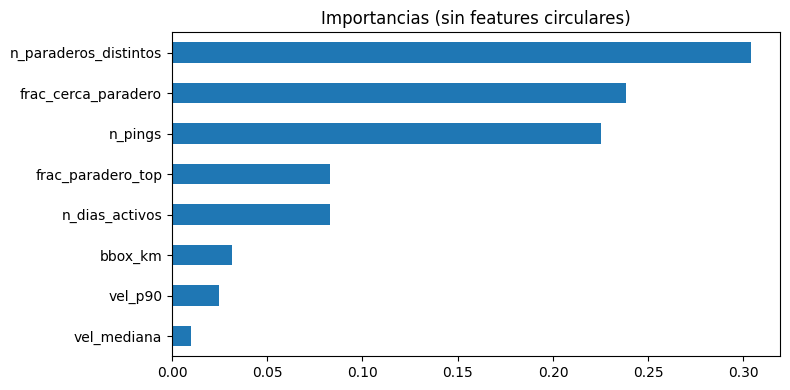

In [ ]:
# Solo features de movilidad — sin los features del matching
cols_movilidad = ['n_pings', 'n_dias_activos', 'frac_cerca_paradero',
                  'vel_mediana', 'vel_p90', 'bbox_km',
                  'n_paraderos_distintos', 'frac_paradero_top']

X_train2 = entrenamiento[cols_movilidad]

modelo2 = RandomForestClassifier(n_estimators=100, random_state=42)
modelo2.fit(X_train2, y_train)

scores2 = cross_val_score(modelo2, X_train2, y_train, cv=5, scoring='accuracy')
print(f"Accuracy cross-validation (sin features circulares): {scores2.mean():.3f} ± {scores2.std():.3f}")

# Aplicar a sin_match
X_smc = features[features['grupo'] == 'sin_match_consistente'][cols_movilidad]
features.loc[features['grupo'] == 'sin_match_consistente', 'pred_clase2'] = modelo2.predict(X_smc)
features.loc[features['grupo'] == 'sin_match_consistente', 'prob_pagador2'] = \
    modelo2.predict_proba(X_smc)[:, list(modelo2.classes_).index('pagador_confirmado')]

print("\nClasificación sin_match (versión limpia):")
smc = features[features['grupo'] == 'sin_match_consistente']
print(smc['pred_clase2'].value_counts())
print(f"Prob promedio de ser pagador: {smc['prob_pagador2'].mean():.2f}")

# Importancias
imp2 = pd.Series(modelo2.feature_importances_, index=cols_movilidad).sort_values(ascending=True)
imp2.plot(kind='barh', figsize=(8,4), title='Importancias (sin features circulares)')
plt.tight_layout()
plt.show()


## 7. Estimación del hogar (exploración)

Se comparó usar la ubicación más frecuente del usuario (modal, todo el día) contra usar
solo los pings nocturnos (22h–7h). Se eligió la versión nocturna porque a esa hora la
persona está en su casa, lo que estima mejor la comuna de residencia. Quedó en
`evasion/hogar.py`.

In [ ]:
import pandas as pd
import numpy as np

# Recargar CDR con todos los días (necesitamos el mes completo para mejor estimación)
import sys, datetime
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from evasion.telefonia import procesar_cdr

cdr_full = procesar_cdr()  # todos los 30 días de noviembre

# Redondear coordenadas a 3 decimales (~100m de precisión)
# para agrupar pings cercanos como "mismo lugar"
cdr_full['lat_r'] = cdr_full['lat'].round(3)
cdr_full['lon_r'] = cdr_full['lon'].round(3)

# Para cada usuario: encontrar su ubicación más frecuente
ubicacion_modal = (
    cdr_full
    .groupby(['user_id', 'lat_r', 'lon_r'])
    .size()
    .reset_index(name='n_veces')
    .sort_values('n_veces', ascending=False)
    .drop_duplicates('user_id')   # quedarse solo con la más frecuente
    [['user_id', 'lat_r', 'lon_r']]
    .rename(columns={'lat_r': 'lat_hogar', 'lon_r': 'lon_hogar'})
)

print(f"Usuarios con ubicación modal: {len(ubicacion_modal):,}")
print(ubicacion_modal.head())


Cargando CDR...
  Registros cargados : 36,268,774
  Tras filtro RM     : 22,343 usuarios
  Tras filtro dias   : 22,343 usuarios, 27,405,224 registros
Usuarios con ubicación modal: 22,343
         user_id  lat_hogar  lon_hogar
3117446   103291    -33.416    -70.534
4197950   138368    -33.461    -70.641
1628642    54461    -33.514    -70.598
574573     19839    -33.498    -70.734
3703055   122269    -33.578    -70.577


In [ ]:
# Pings nocturnos = entre 22h y 7h (hora de dormir en casa)
cdr_full['hora'] = pd.to_datetime(cdr_full['timestamp']).dt.hour
pings_noche = cdr_full[(cdr_full['hora'] >= 22) | (cdr_full['hora'] <= 7)].copy()

print(f"Pings nocturnos: {len(pings_noche):,}")
print(f"Usuarios con al menos 1 ping nocturno: {pings_noche['user_id'].nunique():,}")

# Modal nocturno = ubicación más frecuente de noche
pings_noche['lat_r'] = pings_noche['lat'].round(3)
pings_noche['lon_r'] = pings_noche['lon'].round(3)

ubicacion_hogar = (
    pings_noche
    .groupby(['user_id', 'lat_r', 'lon_r'])
    .size()
    .reset_index(name='n_noches')
    .sort_values('n_noches', ascending=False)
    .drop_duplicates('user_id')
    [['user_id', 'lat_r', 'lon_r']]
    .rename(columns={'lat_r': 'lat_hogar', 'lon_r': 'lon_hogar'})
)

print(f"\nUsuarios con ubicación de hogar estimada: {len(ubicacion_hogar):,}")

# Asignar comuna a ubicacion_hogar
from sklearn.neighbors import BallTree
import numpy as np
import pandas as pd

paraderos = pd.read_csv('../data/gtfs/paradas/paraderos_coords.csv').dropna(subset=['lat','lon']).reset_index(drop=True)
tree = BallTree(np.radians(paraderos[['lat','lon']].values), metric='haversine')

coords = np.radians(ubicacion_hogar[['lat_hogar','lon_hogar']].values)
dist, idx = tree.query(coords, k=1)
ubicacion_hogar['paradero_cod']    = paraderos.iloc[idx.flatten()]['paradero'].values
ubicacion_hogar['dist_paradero_m'] = dist.flatten() * 6_371_000

dtpm = pd.read_excel('../data/gtfs/paradas/2026-03-21_consolidado_Registro-Paradas_anual.xlsx')
dtpm.columns = ['orden','codigo_ts','codigo_usuario','sentido','variante','un',
                'codigo_paradero','codigo_paradero_usuario','comuna','eje',
                'desde','hacia','x','y','nombre','zona_paga','excepciones']
paradero_comuna = dtpm[['codigo_paradero','comuna']].drop_duplicates()

ubicacion_hogar = ubicacion_hogar.merge(
    paradero_comuna.rename(columns={'codigo_paradero':'paradero_cod'}),
    on='paradero_cod', how='left'
)
print(f"Usuarios con comuna asignada: {ubicacion_hogar['comuna'].notna().sum():,}")
print(f"Sin comuna: {ubicacion_hogar['comuna'].isna().sum():,}")


Pings nocturnos: 2,685,574
Usuarios con al menos 1 ping nocturno: 20,170

Usuarios con ubicación de hogar estimada: 20,170
Usuarios con comuna asignada: 17,898
Sin comuna: 2,272


## 8. Evasión por comuna y correlación con pobreza (primera versión)

Primera agregación por comuna y cruce con pobreza comunal. Aquí se exploraron los
umbrales de usuarios mínimos por comuna (20, luego 50) y se calculó la correlación de
Spearman. Esta línea evolucionó hacia `evasion/socioeconomico.py` y el análisis
espacial con LISA.

In [ ]:
# Juntar ubicacion_hogar con features (labels del clasificador)
features = pd.read_parquet('../data/features_usuarios.parquet')

usuarios_con_comuna = ubicacion_hogar.merge(
    features[['user_id', 'grupo', 'pred_clase2']],
    on='user_id',
    how='left'
)

# Etiquetar a cada usuario como evasor, pagador, o no_usuario
def etiquetar_final(row):
    if row['grupo'] == 'pagador_confirmado':
        return 'pagador'
    if row['grupo'] == 'sin_candidatos':
        return 'no_usuario'
    if row['grupo'] == 'sin_match_consistente' and row['pred_clase2'] == 'pagador_confirmado':
        return 'evasor_probable'
    return 'no_clasificado'

usuarios_con_comuna['tipo'] = usuarios_con_comuna.apply(etiquetar_final, axis=1)

print(usuarios_con_comuna['tipo'].value_counts())

# Agregar por comuna
por_comuna = (usuarios_con_comuna
    .dropna(subset=['comuna'])
    .groupby(['comuna', 'tipo'])
    .size()
    .reset_index(name='n')
    .pivot(index='comuna', columns='tipo', values='n')
    .fillna(0)
)

# Calcular tasa de evasión estimada por comuna
# = evasores / (evasores + pagadores)
por_comuna['tasa_evasion'] = (
    por_comuna.get('evasor_probable', 0) /
    (por_comuna.get('evasor_probable', 0) + por_comuna.get('pagador', 0) + 0.0001)
)

por_comuna = por_comuna.sort_values('tasa_evasion', ascending=False)
print("\nComunas con mayor tasa de evasión estimada:")
print(por_comuna[['pagador', 'evasor_probable', 'tasa_evasion']].head(15).round(2))


tipo
no_clasificado     10358
evasor_probable     4406
no_usuario          3581
pagador             1825
Name: count, dtype: int64

Comunas con mayor tasa de evasión estimada:
tipo                 pagador  evasor_probable  tasa_evasion
comuna                                                     
SAN BERNARDO            19.0            208.0          0.92
LA PINTANA              10.0            108.0          0.92
LAMPA                    3.0             32.0          0.91
SAN MIGUEL              10.0            103.0          0.91
PEDRO AGUIRRE CERDA      9.0             78.0          0.90
COLINA                   4.0             29.0          0.88
EL BOSQUE               10.0             68.0          0.87
PADRE HURTADO           12.0             81.0          0.87
LA GRANJA               11.0             62.0          0.85
HUECHURABA              14.0             77.0          0.85
PIRQUE                   4.0             21.0          0.84
SAN JOAQUÍN             17.0             80.

In [ ]:
# Recalcular por comuna solo con usuarios filtrados
por_comuna = (usuarios_con_comuna
    .dropna(subset=['comuna'])
    .groupby(['comuna', 'tipo'])
    .size()
    .reset_index(name='n')
    .pivot(index='comuna', columns='tipo', values='n')
    .fillna(0)
)

por_comuna['total_transit'] = por_comuna.get('pagador', 0) + por_comuna.get('evasor_probable', 0)
por_comuna['tasa_evasion']  = (
    por_comuna.get('evasor_probable', 0) / (por_comuna['total_transit'] + 0.0001)
)

# Solo comunas con al menos 20 usuarios de transporte — muestra mínima confiable
por_comuna_filtrada = por_comuna[por_comuna['total_transit'] >= 20].sort_values('tasa_evasion', ascending=False)

print(f"Comunas con >= 20 usuarios de transporte: {len(por_comuna_filtrada)}")
print(por_comuna_filtrada[['pagador','evasor_probable','total_transit','tasa_evasion']].round(2))
por_comuna_filtrada.to_parquet('../data/evasion_por_comuna.parquet')
print("Guardado")


Comunas con >= 20 usuarios de transporte: 38
tipo                 pagador  evasor_probable  total_transit  tasa_evasion
comuna                                                                    
SAN BERNARDO            19.0            208.0          227.0          0.92
LA PINTANA              10.0            108.0          118.0          0.92
LAMPA                    3.0             32.0           35.0          0.91
SAN MIGUEL              10.0            103.0          113.0          0.91
PEDRO AGUIRRE CERDA      9.0             78.0           87.0          0.90
COLINA                   4.0             29.0           33.0          0.88
EL BOSQUE               10.0             68.0           78.0          0.87
PADRE HURTADO           12.0             81.0           93.0          0.87
LA GRANJA               11.0             62.0           73.0          0.85
HUECHURABA              14.0             77.0           91.0          0.85
PIRQUE                   4.0             21.0          

In [ ]:
pobreza = pd.read_excel('../data/pobreza_comunal.xlsx', skiprows=1, header=0)

# Usar la primera fila como nombres de columna
pobreza.columns = pobreza.iloc[0].values
pobreza = pobreza.iloc[1:].reset_index(drop=True)

print(pobreza.columns.tolist())
print(pobreza.head(3))


['Código', 'Región', 'Nombre comuna', 'Número de personas según proyecciones de población (*)', 'Número de personas en situación de pobreza por ingresos (**)', 'Porcentaje de personas en situación de pobreza por ingresos 2022', 'Límite inferior\n (***)', 'Límite superior', 'Presencia de la comuna en la muestra Casen', 'Tipo de estimación SAE \n(****)']
  Código    Región  Nombre comuna  \
0   1101  Tarapacá        Iquique   
1   1107  Tarapacá  Alto Hospicio   
2   1401  Tarapacá   Pozo Almonte   

  Número de personas según proyecciones de población (*)  \
0                                             229674       
1                                             138527       
2                                              18290       

  Número de personas en situación de pobreza por ingresos (**)  \
0                                              18122             
1                                              21144             
2                                               2805     

In [ ]:
rm = pobreza[pobreza['Código'].astype(str).str.startswith('13')].copy()
rm = rm[['Nombre comuna', 'Porcentaje de personas en situación de pobreza por ingresos 2022']].copy()
rm.columns = ['comuna', 'tasa_pobreza']
rm['tasa_pobreza'] = rm['tasa_pobreza'].astype(float)
rm['comuna'] = rm['comuna'].str.upper().str.strip()

print(f"Comunas RM: {len(rm)}")
print(rm.head(10))


Comunas RM: 52
               comuna  tasa_pobreza
256          SANTIAGO      0.038648
257         CERRILLOS      0.052287
258       CERRO NAVIA      0.060135
259          CONCHALÍ      0.060799
260         EL BOSQUE      0.061982
261  ESTACIÓN CENTRAL      0.050424
262        HUECHURABA      0.042766
263     INDEPENDENCIA      0.058340
264       LA CISTERNA      0.040923
265        LA FLORIDA      0.035299


In [ ]:
from scipy import stats

# Merge por nombre de comuna
analisis = por_comuna_filtrada.merge(rm, on='comuna', how='inner')

print(f"Comunas en tu tabla de evasión: {len(por_comuna_filtrada)}")
print(f"Comunas en CASEN: {len(rm)}")
print(f"Comunas con ambos datos: {len(analisis)}")
print("\nComunas sin match (pueden tener nombres distintos):")
por_comuna_filtrada = por_comuna_filtrada.reset_index()
sin_match = por_comuna_filtrada[~por_comuna_filtrada['comuna'].isin(rm['comuna'])]['comuna'].tolist()
print(sin_match)


Comunas en tu tabla de evasión: 38
Comunas en CASEN: 52
Comunas con ambos datos: 38

Comunas sin match (pueden tener nombres distintos):
[]


Correlación de Spearman: 0.312
P-valor: 0.0569
No significativa (α=0.05)


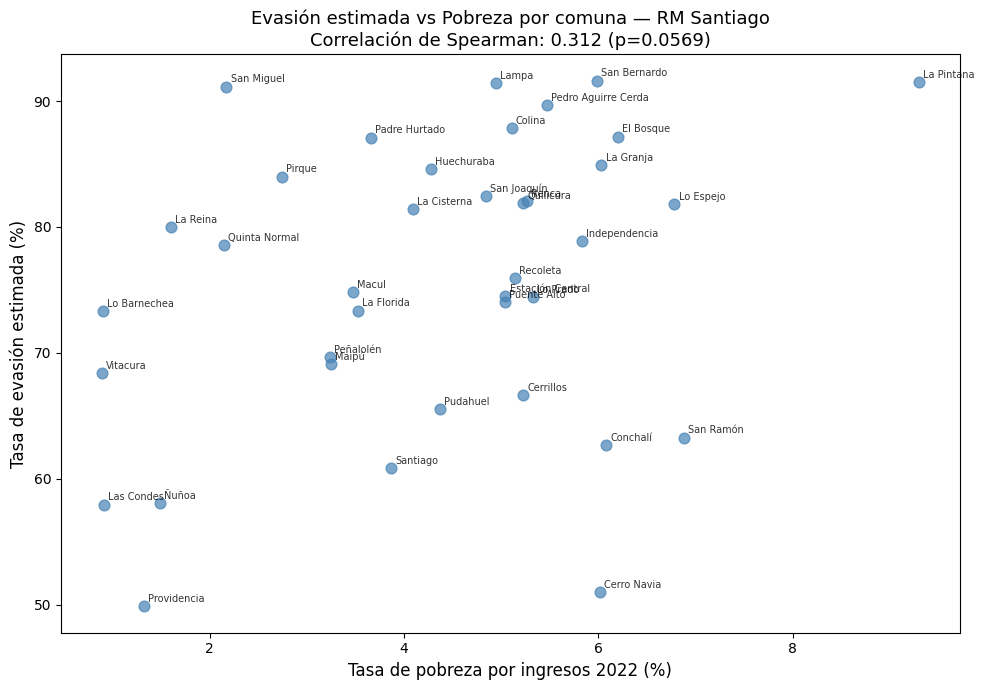

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

# Correlación de Spearman (no asume distribución normal)
corr, pvalor = stats.spearmanr(analisis['tasa_evasion'], analisis['tasa_pobreza'])
print(f"Correlación de Spearman: {corr:.3f}")
print(f"P-valor: {pvalor:.4f}")
print(f"{'Significativa' if pvalor < 0.05 else 'No significativa'} (α=0.05)")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(analisis['tasa_pobreza'] * 100,
           analisis['tasa_evasion'] * 100,
           alpha=0.7, s=60, color='steelblue')

# Etiquetar cada punto con el nombre de la comuna
for _, row in analisis.iterrows():
    ax.annotate(row['comuna'].title(),
                (row['tasa_pobreza'] * 100, row['tasa_evasion'] * 100),
                fontsize=7, alpha=0.8,
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Tasa de pobreza por ingresos 2022 (%)', fontsize=12)
ax.set_ylabel('Tasa de evasión estimada (%)', fontsize=12)
ax.set_title(f'Evasión estimada vs Pobreza por comuna — RM Santiago\n'
             f'Correlación de Spearman: {corr:.3f} (p={pvalor:.4f})',
             fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/correlacion_evasion_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()
